In [33]:
import os
print(os.getpid())
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import seaborn.objects as so
from matplotlib.ticker import MultipleLocator

import sys
sys.path.append('../../')
# from tools.helpers.db_helpers import get_engine
from datetime import datetime, date
from dateutil.relativedelta import relativedelta
import numpy as np
from IPython import embed

from IPython.display import clear_output
import json
import pytz
import pydytuesday
import chardet

516


In [34]:
pydytuesday.get_date('2025-01-21')

Trying to fetch README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2025/2025-01-21/readme.md
Successfully fetched README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2025/2025-01-21/readme.md
Successfully saved exped_tidy.csv to /workspaces/data_template/notebooks/himalayas/exped_tidy.csv
Successfully saved himalayas.png to /workspaces/data_template/notebooks/himalayas/himalayas.png
Successfully saved meta.yaml to /workspaces/data_template/notebooks/himalayas/meta.yaml
Successfully saved peaks_tidy.csv to /workspaces/data_template/notebooks/himalayas/peaks_tidy.csv


In [35]:
peaks_tidy_df = pd.read_csv("peaks_tidy.csv")
peaks_tidy_df

,PEAKID,PKNAME,PKNAME2,LOCATION,HEIGHTM,HEIGHTF,HIMAL,HIMAL_FACTOR,REGION,REGION_FACTOR,...,PEAKMEMO,PYEAR,PSEASON,PEXPID,PSMTDATE,PCOUNTRY,PSUMMITERS,PSMTNOTE,REFERMEMO,PHOTOMEMO
0,AMAD,Ama Dablam,Amai Dablang,Khumbu Himal,6814,22356,12,Khumbu,2,Khumbu-Rolwaling-Makalu,...,8.0,1961.0,1,AMAD61101,Mar 13,"New Zealand, USA, UK","Mike Gill, Wally Romanes, Barry Bishop, Michae...",NaN,NaN,13.0
1,AMPG,Amphu Gyabjen,Amphu Gyabien,Khumbu Himal (N of Ama Dablam),5630,18471,12,Khumbu,2,Khumbu-Rolwaling-Makalu,...,20.0,1953.0,1,AMPG53101,Apr 11,UK,"John Hunt, Tom Bourdillon",NaN,NaN,NaN
2,ANN1,Annapurna I,NaN,Annapurna Himal,8091,26545,1,Annapurna,5,Annapurna-Damodar-Peri,...,23.0,1950.0,1,ANN150101,Jun 03,France,"Maurice Herzog, Louis Lachenal",NaN,25.0,26.0
3,ANN2,Annapurna II,NaN,Annapurna Himal,7937,26040,1,Annapurna,5,Annapurna-Damodar-Peri,...,31.0,1960.0,1,ANN260101,May 17,"UK, Nepal","Richard Grant, Chris Bonington, Ang Nyima Sherpa",NaN,33.0,34.0
4,ANN3,Annapurna III,NaN,Annapurna Himal,7555,24787,1,Annapurna,5,Annapurna-Damodar-Peri,...,35.0,1961.0,1,ANN361101,May 06,India,"Mohan S. Kohli, Sonam Gyatso, Sonam Girmi",NaN,NaN,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,JUG3,Jugal 3,NaN,Jugal Himal (SE of Dorje Lakpa),6184,20289,8,Jugal,3,Langtang-Jugal,...,1372.0,2024.0,2,JUG324201,Jun 11,"Japan, Nepal","Yoshio Kitajima, Phura Chhiri Sherpa",NaN,NaN,NaN
476,JUG4,Jugal 4,NaN,Jugal Himal (SSE of Dorje Lakpa),5936,19475,8,Jugal,3,Langtang-Jugal,...,1373.0,NaN,0,NaN,NaN,NaN,Unclimbed,NaN,NaN,NaN
477,JUG5,Jugal 5,NaN,Jugal Himal (W of Yangri),5922,19429,8,Jugal,3,Langtang-Jugal,...,1374.0,2023.0,3,JUG523301,Oct 24,"USA, Mexico, Nepal","Tenzing Jangbu Sherpa, Nima Gyalzen Sherpa, Sa...",NaN,NaN,NaN
478,LNPS,Langpo South,NaN,Jongsang Himal (SE of Langpo on Indian border),6857,22497,7,Jongsang,1,Kangchenjunga-Janak,...,1375.0,1939.0,2,LNPS39201,Aug 19,"Switzerland, Germany","Ernt Grob, Herbert Paidar, Ludwig Schmaderer",NaN,NaN,NaN


In [36]:
# Display the first few rows
print(peaks_tidy_df.head())


  PEAKID         PKNAME        PKNAME2                        LOCATION  \
0   AMAD     Ama Dablam   Amai Dablang                    Khumbu Himal   
1   AMPG  Amphu Gyabjen  Amphu Gyabien  Khumbu Himal (N of Ama Dablam)   
2   ANN1    Annapurna I            NaN                 Annapurna Himal   
3   ANN2   Annapurna II            NaN                 Annapurna Himal   
4   ANN3  Annapurna III            NaN                 Annapurna Himal   

   HEIGHTM  HEIGHTF  HIMAL HIMAL_FACTOR  REGION            REGION_FACTOR  ...  \
0     6814    22356     12       Khumbu       2  Khumbu-Rolwaling-Makalu  ...   
1     5630    18471     12       Khumbu       2  Khumbu-Rolwaling-Makalu  ...   
2     8091    26545      1    Annapurna       5   Annapurna-Damodar-Peri  ...   
3     7937    26040      1    Annapurna       5   Annapurna-Damodar-Peri  ...   
4     7555    24787      1    Annapurna       5   Annapurna-Damodar-Peri  ...   

   PEAKMEMO   PYEAR  PSEASON     PEXPID PSMTDATE              PCOUNT

In [37]:

# Get basic information about the dataset
print(peaks_tidy_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PEAKID          480 non-null    object 
 1   PKNAME          480 non-null    object 
 2   PKNAME2         257 non-null    object 
 3   LOCATION        479 non-null    object 
 4   HEIGHTM         480 non-null    int64  
 5   HEIGHTF         480 non-null    int64  
 6   HIMAL           480 non-null    int64  
 7   HIMAL_FACTOR    480 non-null    object 
 8   REGION          480 non-null    int64  
 9   REGION_FACTOR   480 non-null    object 
 10  OPEN            480 non-null    bool   
 11  UNLISTED        480 non-null    bool   
 12  TREKKING        480 non-null    bool   
 13  TREKYEAR        29 non-null     float64
 14  RESTRICT        275 non-null    object 
 15  PHOST           480 non-null    int64  
 16  PHOST_FACTOR    480 non-null    object 
 17  PSTATUS         480 non-null    int

In [38]:

# Generate summary statistics
print(peaks_tidy_df.describe())


           HEIGHTM       HEIGHTF       HIMAL      REGION     TREKYEAR  \
count   480.000000    480.000000  480.000000  480.000000    29.000000   
mean   6648.977083  21814.245833   10.252083    3.802083  1918.758621   
std     572.676102   1878.862588    5.536461    2.139302   365.364168   
min    5407.000000  17740.000000    1.000000    1.000000    20.000000   
25%    6235.000000  20456.000000    6.000000    2.000000  1978.000000   
50%    6552.500000  21497.500000   11.000000    4.000000  1978.000000   
75%    6900.500000  22639.750000   15.000000    6.000000  2002.000000   
max    8849.000000  29032.000000   20.000000    7.000000  2002.000000   

            PHOST     PSTATUS     PEAKMEMO        PYEAR     PSEASON  \
count  480.000000  480.000000   475.000000   362.000000  480.000000   
mean     2.112500    1.766667   791.271579  1986.624309    1.581250   
std      1.512595    0.423394   380.433475    25.147152    1.246985   
min      1.000000    1.000000     8.000000  1909.000000   

In [42]:
peaks_tidy_df.columns

Index(['PEAKID', 'PKNAME', 'PKNAME2', 'LOCATION', 'HEIGHTM', 'HEIGHTF',
       'HIMAL', 'HIMAL_FACTOR', 'REGION', 'REGION_FACTOR', 'OPEN', 'UNLISTED',
       'TREKKING', 'TREKYEAR', 'RESTRICT', 'PHOST', 'PHOST_FACTOR', 'PSTATUS',
       'PSTATUS_FACTOR', 'PEAKMEMO', 'PYEAR', 'PSEASON', 'PEXPID', 'PSMTDATE',
       'PCOUNTRY', 'PSUMMITERS', 'PSMTNOTE', 'REFERMEMO', 'PHOTOMEMO'],
      dtype='object')

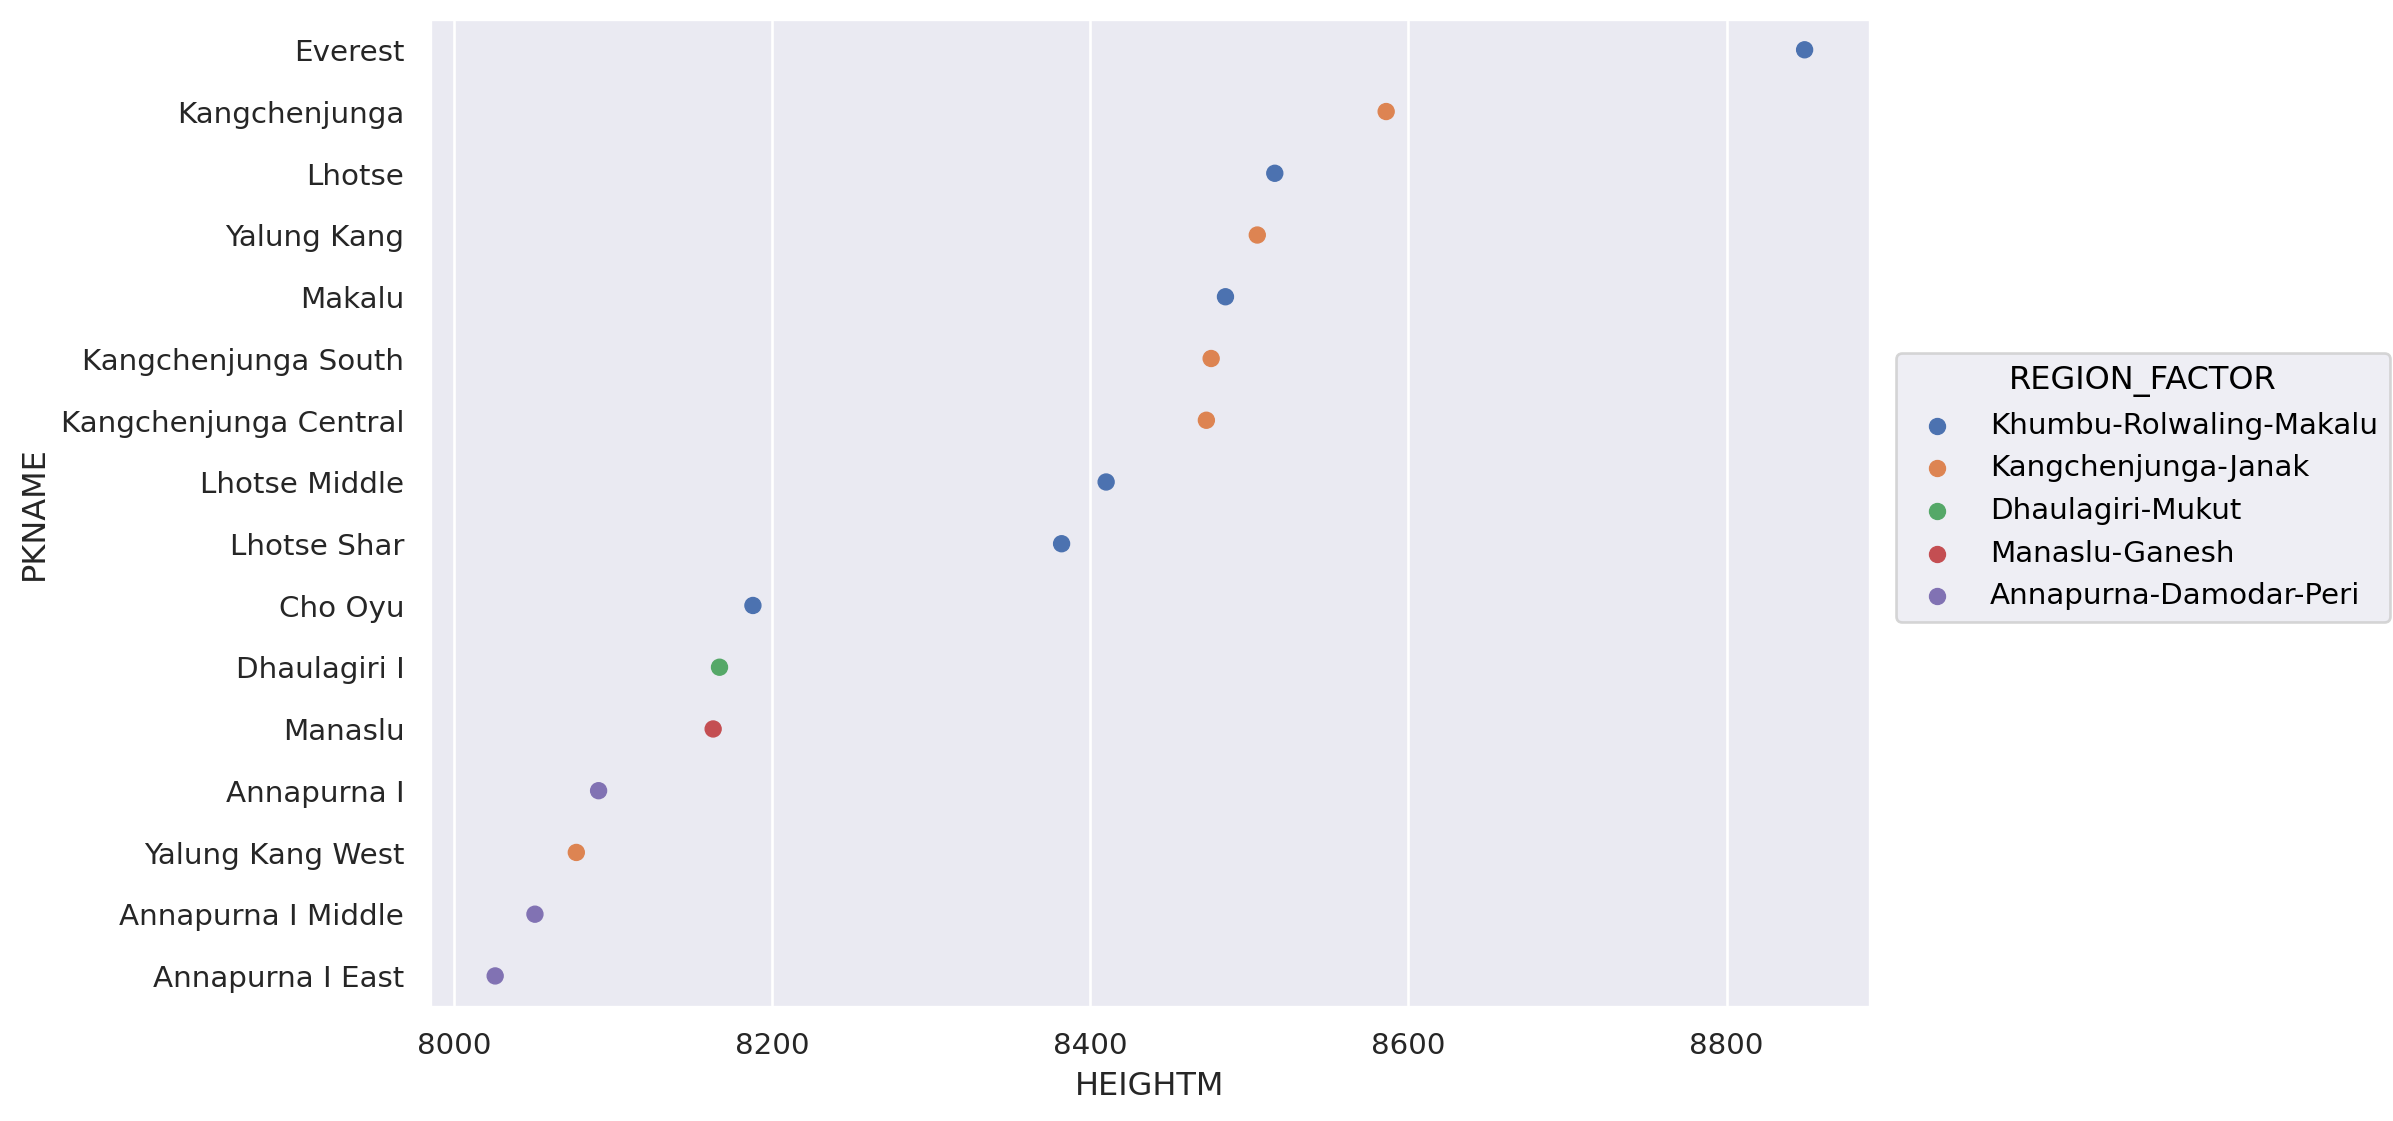

In [50]:
peaks_tidy_df_sort = peaks_tidy_df.sort_values("HEIGHTM", ascending = False)
peaks_tidy_df_sort_top = peaks_tidy_df_sort[peaks_tidy_df_sort["HEIGHTM"] > 8000]
(
    so.Plot(peaks_tidy_df_sort_top, x="HEIGHTM", y="PKNAME", color="REGION_FACTOR")
    .add(so.Dot())
    .layout(size=(10, 6))
)

In [58]:
# peaks_tidy_df[peaks_tidy_df["HEIGHTM"] > 8000]

peaks_tidy_df.query("HEIGHTM > 8000")

,PEAKID,PKNAME,PKNAME2,LOCATION,HEIGHTM,HEIGHTF,HIMAL,HIMAL_FACTOR,REGION,REGION_FACTOR,...,PEAKMEMO,PYEAR,PSEASON,PEXPID,PSMTDATE,PCOUNTRY,PSUMMITERS,PSMTNOTE,REFERMEMO,PHOTOMEMO
2,ANN1,Annapurna I,NaN,Annapurna Himal,8091,26545,1,Annapurna,5,Annapurna-Damodar-Peri,...,23.0,1950.0,1,ANN150101,Jun 03,France,"Maurice Herzog, Louis Lachenal",NaN,25.0,26.0
6,ANNE,Annapurna I East,NaN,Annapurna Himal (ENE of Annapurna I),8026,26332,1,Annapurna,5,Annapurna-Damodar-Peri,...,44.0,1974.0,1,ANNE74101,Apr 29,Spain,"Jose Manuel Anglada Nieto, Jorge Pons Sangines...",NaN,NaN,45.0
7,ANNM,Annapurna I Middle,NaN,Annapurna Himal (ENE of Annapurna I),8051,26414,1,Annapurna,5,Annapurna-Damodar-Peri,...,46.0,1980.0,3,ANNM80301,Oct 03,W Germany,"Udo Boening, Ludwig Greissl, Heinz Oberrauch",NaN,NaN,NaN
20,CHOY,Cho Oyu,NaN,Khumbu Himal (NW of Everest on Tibetan border),8188,26864,12,Khumbu,2,Khumbu-Rolwaling-Makalu,...,97.0,1954.0,3,CHOY54301,Oct 19,"Austria, Nepal","Herbert Tichy, Sepp Jeochler, Pasang Dawa Lama",NaN,101.0,102.0
30,DHA1,Dhaulagiri I,NaN,Dhaulagiri Himal,8167,26795,4,Dhaulagiri,6,Dhaulagiri-Mukut,...,140.0,1960.0,1,DHA160101,May 13,"Switzerland, Austria, W Germany, Nepal","Peter Diener, Kurt Diemberger, Albin Schelbert...",NaN,142.0,143.0
42,EVER,Everest,"Sagarmatha, Chomolungma, Qomolungma",Khumbu Himal,8849,29032,12,Khumbu,2,Khumbu-Rolwaling-Makalu,...,184.0,1953.0,1,EVER53101,May 29,"New Zealand, India","Edmund Hillary, Tenzing Norgay Sherpa",NaN,199.0,200.0
89,KANC,Kangchenjunga Central,NaN,Kangchenjunga Himal (between Main and South su...,8473,27799,9,Kangchenjunga/Simhalila,1,Kangchenjunga-Janak,...,363.0,1978.0,1,KANC78102,May 22,Poland,"Wojciech Branski, Zygmunt Heinrich, Kazimierz ...",Illegal ascent,NaN,365.0
91,KANG,Kangchenjunga,NaN,Kangchenjunga Himal,8586,28169,9,Kangchenjunga/Simhalila,1,Kangchenjunga-Janak,...,369.0,1955.0,1,KANG55101,May 25,UK,"George Band, Joe Brown",NaN,372.0,373.0
92,KANS,Kangchenjunga South,NaN,Kangchenjunga Himal,8476,27808,9,Kangchenjunga/Simhalila,1,Kangchenjunga-Janak,...,378.0,1978.0,1,KANS78101,May 19,Poland,"Eugeniusz Chrobak, Wojciech Wroz",NaN,NaN,380.0
112,LHOT,Lhotse,NaN,Khumbu Himal,8516,27940,12,Khumbu,2,Khumbu-Rolwaling-Makalu,...,444.0,1956.0,1,LHOT56101,May 18,Switzerland,"Fritz Luchsinger, Ernst Reiss",NaN,447.0,448.0


In [41]:
exped_tidy_df = pd.read_csv("exped_tidy.csv")
exped_tidy_df

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x92 in position 37355: invalid start byte

In [ ]:

with open("exped_tidy.csv", "rb") as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [ ]:
exped_tidy_df = pd.read_csv("exped_tidy.csv", encoding="Windows-1252")
exped_tidy_df

,EXPID,PEAKID,YEAR,SEASON,SEASON_FACTOR,HOST,HOST_FACTOR,ROUTE1,ROUTE2,ROUTE3,...,ACCIDENTS,ACHIEVMENT,AGENCY,COMRTE,STDRTE,PRIMRTE,PRIMMEM,PRIMREF,PRIMID,CHKSUM
0,EVER20101,EVER,2020,1,Spring,2,China,N Col-NE Ridge,NaN,NaN,...,NaN,NaN,Holy Mountain Adventure,True,True,False,False,False,NaN,2465291
1,EVER20102,EVER,2020,1,Spring,2,China,N Col-NE Ridge,NaN,NaN,...,NaN,NaN,NaN,True,True,False,False,False,NaN,2465292
2,EVER20103,EVER,2020,1,Spring,2,China,N Col-NE Ridge,NaN,NaN,...,NaN,NaN,Holy Mountain Adventure,True,True,False,False,False,NaN,2465293
3,AMAD20301,AMAD,2020,3,Autumn,1,Nepal,SW Ridge,NaN,NaN,...,NaN,NaN,Seven Summit Treks,True,False,False,False,False,NaN,2463299
4,AMAD20302,AMAD,2020,3,Autumn,1,Nepal,SW Ridge,NaN,NaN,...,NaN,NaN,Himalayan Guides,True,False,False,False,False,NaN,2463299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,PATR24201,PATR,2024,2,Summer,1,Nepal,NW Ridge,NaN,NaN,...,NaN,NaN,NaN,False,False,False,False,False,NaN,2463218
878,PUMO24101,PUMO,2024,1,Spring,1,Nepal,SE Face,NaN,NaN,...,NaN,NaN,Asian Trekking,False,False,False,False,False,NaN,2789
879,PUTH24101,PUTH,2024,1,Spring,1,Nepal,NE Face,NaN,NaN,...,NaN,NaN,Holiday Himalaya Treks,False,False,False,False,False,NaN,2463320
880,TKPO24101,TKPO,2024,1,Spring,1,Nepal,NE Face,NaN,NaN,...,NaN,NaN,iTrek Nepal,False,False,False,False,False,NaN,2463393


In [ ]:
# Display the first few rows
print(exped_tidy_df.head())


       EXPID PEAKID  YEAR  SEASON SEASON_FACTOR  HOST HOST_FACTOR  \
0  EVER20101   EVER  2020       1        Spring     2       China   
1  EVER20102   EVER  2020       1        Spring     2       China   
2  EVER20103   EVER  2020       1        Spring     2       China   
3  AMAD20301   AMAD  2020       3        Autumn     1       Nepal   
4  AMAD20302   AMAD  2020       3        Autumn     1       Nepal   

           ROUTE1 ROUTE2  ROUTE3  ...  ACCIDENTS ACHIEVMENT  \
0  N Col-NE Ridge    NaN     NaN  ...        NaN        NaN   
1  N Col-NE Ridge    NaN     NaN  ...        NaN        NaN   
2  N Col-NE Ridge    NaN     NaN  ...        NaN        NaN   
3        SW Ridge    NaN     NaN  ...        NaN        NaN   
4        SW Ridge    NaN     NaN  ...        NaN        NaN   

                    AGENCY COMRTE  STDRTE  PRIMRTE  PRIMMEM  PRIMREF PRIMID  \
0  Holy Mountain Adventure   True    True    False    False    False    NaN   
1                      NaN   True    True    Fal

In [ ]:

# Get basic information about the dataset
print(exped_tidy_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 69 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EXPID              882 non-null    object 
 1   PEAKID             882 non-null    object 
 2   YEAR               882 non-null    int64  
 3   SEASON             882 non-null    int64  
 4   SEASON_FACTOR      882 non-null    object 
 5   HOST               882 non-null    int64  
 6   HOST_FACTOR        882 non-null    object 
 7   ROUTE1             862 non-null    object 
 8   ROUTE2             43 non-null     object 
 9   ROUTE3             0 non-null      float64
 10  ROUTE4             0 non-null      float64
 11  NATION             882 non-null    object 
 12  LEADERS            882 non-null    object 
 13  SPONSOR            882 non-null    object 
 14  SUCCESS1           882 non-null    bool   
 15  SUCCESS2           882 non-null    bool   
 16  SUCCESS3           882 non

In [ ]:

# Generate summary statistics
print(exped_tidy_df.describe())


              YEAR      SEASON        HOST  ROUTE3  ROUTE4  ASCENT3  ASCENT4  \
count   882.000000  882.000000  882.000000     0.0     0.0      0.0      0.0   
mean   2022.252834    1.970522    1.032880     NaN     NaN      NaN      NaN   
std       1.017786    1.032521    0.190723     NaN     NaN      NaN      NaN   
min    2020.000000    1.000000    1.000000     NaN     NaN      NaN      NaN   
25%    2021.000000    1.000000    1.000000     NaN     NaN      NaN      NaN   
50%    2022.000000    1.000000    1.000000     NaN     NaN      NaN      NaN   
75%    2023.000000    3.000000    1.000000     NaN     NaN      NaN      NaN   
max    2024.000000    4.000000    3.000000     NaN     NaN      NaN      NaN   

           SMTTIME     SMTDAYS     TOTDAYS  ...       CAMPS         ROPE  \
count   365.000000  882.000000  882.000000  ...  882.000000   882.000000   
mean    962.564384    8.024943    8.998866  ...    2.521542    19.444444   
std     369.541681   12.094945   14.002473  ...    

In [ ]:

# Perform data analysis and visualization
import matplotlib.pyplot as plt
exped_tidy_df.plot(kind='bar', x='SEASON_FACTOR', y='HOST')
plt.title('TidyTuesday Data Analysis')
plt.show()